In [ ]:
!pip install nltk
!pip install numpy
!pip install tensorflow
!pip install gensim


In [ ]:
import pandas as pd
import numpy as np
import nltk
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from nltk.tokenize import word_tokenize

# Download nltk data (for tokenization)
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
data = pd.read_csv('modified_data.csv')  # Replace 'your_dataset.csv' with your actual file name
data.columns = ['label', 'id', 'text']  # Adjust column names if needed
print(data.head())

   label  id                                               text
0      0   1  former versace store clerk sues over secret 'b...
1      0   2  the 'roseanne' revival catches up to our thorn...
2      1   3  mom starting to fear son's web series closest ...
3      1   4  boehner just wants wife to listen, not come up...
4      0   5  j.k. rowling wishes snape happy birthday in th...


In [ ]:
def chunk_text(text, n_chunks=2):
    words = word_tokenize(text)
    chunk_size = max(1, len(words) // n_chunks)
    chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]
    return chunks[:n_chunks]  # Return only the specified number of chunks

# Example usage
data['chunks'] = data['text'].apply(lambda x: chunk_text(x, n_chunks=2))


In [ ]:
# Load pre-trained word embeddings
word_vectors = api.load('glove-wiki-gigaword-100')  # 100-dimensional GloVe embeddings

# Define seed words for each emotion category
emotion_seeds = {
    'anger': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happiness': 'happy',
    'sadness': 'sad',
    'surprise': 'surprise'
}

# Compute emotion vector for each word in the chunk
def compute_emotion_vector(word):
    if word in word_vectors:
        return np.array([word_vectors.similarity(word, seed) if seed in word_vectors else 0
                         for seed in emotion_seeds.values()])
    else:
        return np.zeros(len(emotion_seeds))

# Compute average emotion vector for each chunk
def compute_chunk_emotion_vector(chunk):
    emotion_vectors = [compute_emotion_vector(word) for word in chunk]
    return np.mean(emotion_vectors, axis=0)

# Apply to each chunk in the dataset
data['emotion_vectors'] = data['chunks'].apply(lambda chunks: [compute_chunk_emotion_vector(chunk) for chunk in chunks])


[==================================================] 100.0% 128.1/128.1MB downloaded


Fixed N chunk n = 2

In [ ]:
# Set a fixed number of chunks
n_chunks = 2
n_emotions = len(emotion_seeds)  # Number of emotions, which should be 6 in this example

# Function to pad or truncate emotion vectors to a fixed number of chunks
def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    # If there are fewer chunks, pad with zeros; if more, truncate to the first n_chunks
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

# Apply padding/truncation to ensure each entry has exactly n_chunks
data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

# Convert to a NumPy array
X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Define the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5581 - loss: 0.6847 - val_accuracy: 0.5754 - val_loss: 0.6773
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5776 - loss: 0.6771 - val_accuracy: 0.5889 - val_loss: 0.6722
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5864 - loss: 0.6705 - val_accuracy: 0.5928 - val_loss: 0.6706
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5917 - loss: 0.6684 - val_accuracy: 0.5990 - val_loss: 0.6697
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5813 - loss: 0.6713 - val_accuracy: 0.5803 - val_loss: 0.6838
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5889 - loss: 0.6683 - val_accuracy: 0.5964 - val_loss: 0.6755
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6026 - loss: 0.6635 - val_accuracy: 0.5958 - val_loss: 0.6653
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6033 - loss: 0.6635 - val_accuracy: 0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5945 - loss: 0.6678
Test Loss: 0.66600102186203, Test Accuracy: 0.6044552326202393


Fixed N chunk n = 3

In [ ]:
# Set a fixed number of chunks
n_chunks = 3
n_emotions = len(emotion_seeds)  # Number of emotions, which should be 6 in this example

# Function to pad or truncate emotion vectors to a fixed number of chunks
def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    # If there are fewer chunks, pad with zeros; if more, truncate to the first n_chunks
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

# Apply padding/truncation to ensure each entry has exactly n_chunks
data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

# Convert to a NumPy array
X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Define the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5633 - loss: 0.6839 - val_accuracy: 0.5730 - val_loss: 0.6793
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5810 - loss: 0.6765 - val_accuracy: 0.5874 - val_loss: 0.6740
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5851 - loss: 0.6713 - val_accuracy: 0.5852 - val_loss: 0.6737
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5851 - loss: 0.6704 - val_accuracy: 0.5887 - val_loss: 0.6715
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5957 - loss: 0.6674 - val_accuracy: 0.5876 - val_loss: 0.6732
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5892 - loss: 0.6679 - val_accuracy: 0.5732 - val_loss: 0.6824
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5897 - loss: 0.6681 - val_accuracy: 0.5863 - val_loss: 0.6727
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5951 - loss: 0.6653 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5937 - loss: 0.6678
Test Loss: 0.667843222618103, Test Accuracy: 0.5964058637619019


Fixed N chunk n = *4*

In [ ]:
# Set a fixed number of chunks
n_chunks = 4
n_emotions = len(emotion_seeds)  # Number of emotions, which should be 6 in this example

# Function to pad or truncate emotion vectors to a fixed number of chunks
def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    # If there are fewer chunks, pad with zeros; if more, truncate to the first n_chunks
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

# Apply padding/truncation to ensure each entry has exactly n_chunks
data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

# Convert to a NumPy array
X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5666 - loss: 0.6826 - val_accuracy: 0.5781 - val_loss: 0.6801
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5788 - loss: 0.6758 - val_accuracy: 0.5865 - val_loss: 0.6722
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5821 - loss: 0.6735 - val_accuracy: 0.5809 - val_loss: 0.6877
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5855 - loss: 0.6740 - val_accuracy: 0.5893 - val_loss: 0.6716
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5851 - loss: 0.6713 - val_accuracy: 0.5784 - val_loss: 0.6900
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5833 - loss: 0.6718 - val_accuracy: 0.5943 - val_loss: 0.6737
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5880 - loss: 0.6715 - val_accuracy: 0.5904 - val_loss: 0.6716
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5968 - loss: 0.6677 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5834 - loss: 0.6699
Test Loss: 0.6707339286804199, Test Accuracy: 0.5857356786727905


Fixed N chunk n = 5

In [ ]:
# Set a fixed number of chunks
n_chunks = 5
n_emotions = len(emotion_seeds)  # Number of emotions, which should be 6 in this example

# Function to pad or truncate emotion vectors to a fixed number of chunks
def pad_or_truncate(emotion_vectors, n_chunks, n_emotions):
    # If there are fewer chunks, pad with zeros; if more, truncate to the first n_chunks
    if len(emotion_vectors) < n_chunks:
        padding = [np.zeros(n_emotions) for _ in range(n_chunks - len(emotion_vectors))]
        emotion_vectors.extend(padding)
    return emotion_vectors[:n_chunks]

# Apply padding/truncation to ensure each entry has exactly n_chunks
data['padded_emotion_vectors'] = data['emotion_vectors'].apply(lambda x: pad_or_truncate(x, n_chunks, n_emotions))

# Convert to a NumPy array
X = np.array(data['padded_emotion_vectors'].to_list())
y = data['label'].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
# Define the LSTM model
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5648 - loss: 0.6836 - val_accuracy: 0.5728 - val_loss: 0.6795
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5796 - loss: 0.6762 - val_accuracy: 0.5758 - val_loss: 0.6736
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5842 - loss: 0.6736 - val_accuracy: 0.5769 - val_loss: 0.6777
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5927 - loss: 0.6695 - val_accuracy: 0.5893 - val_loss: 0.6701
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5928 - loss: 0.6691 - val_accuracy: 0.5878 - val_loss: 0.6705
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5929 - loss: 0.6670 - val_accuracy: 0.5902 - val_loss: 0.6683
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5841 - loss: 0.6690 - val_accuracy: 0.5900 - val_loss: 0.6682
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5891 - loss: 0.6694 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6100 - loss: 0.6608
Test Loss: 0.6665300726890564, Test Accuracy: 0.5984649658203125


K fixed chunking where k = 2



In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Assuming word_vectors is your pre-trained GloVe embeddings dictionary
word_embeddings = word_vectors  # Word embeddings from GloVe or other sources

# Seed words for emotions: anger, disgust, fear, happiness, sadness, surprise
emotion_seeds = {
    "anger": "angry",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "happy",
    "sad": "sad",
    "surprise": "surprised"
}

# Function to compute emotion vector for a word based on GloVe embeddings
def compute_emotion_vector_for_word(word, emotion_seeds, word_embeddings):
    if word in word_embeddings:
        word_vector = word_embeddings[word]
        emotion_vector = []
        for emotion, seed_word in emotion_seeds.items():
            if seed_word in word_embeddings:
                seed_vector = word_embeddings[seed_word]
                sim = cosine_similarity([word_vector], [seed_vector])[0][0]
                emotion_vector.append(sim)
            else:
                # If seed word is not found, append zero for that emotion
                emotion_vector.append(0)
        return np.array(emotion_vector)
    else:
        # If the word is not in the GloVe embeddings, return zero vector for emotions
        return np.zeros(len(emotion_seeds))

# Function to split the text into fixed-length chunks
def fixed_k_chunking(text, k):
    words = text.split()  # Split sentence into words
    # Generate chunks of size k
    chunks = [words[i:i + k] for i in range(0, len(words), k)]
    return chunks

# Function to calculate emotion vector for a chunk (average of word emotion vectors)
def compute_emotion_vector_for_chunk(chunk, emotion_seeds, word_embeddings):
    emotion_vectors = []
    for word in chunk:
        emotion_vector = compute_emotion_vector_for_word(word, emotion_seeds, word_embeddings)
        emotion_vectors.append(emotion_vector)
    # Calculate average emotion vector for the chunk
    return np.mean(emotion_vectors, axis=0)

# Function to pad or truncate the emotion vectors to maintain a consistent number of chunks
def pad_or_truncate(emotion_vectors, k):
    if len(emotion_vectors) < k:
        # Pad with zero vectors if there are fewer chunks than k
        padding = [np.zeros(len(emotion_seeds)) for _ in range(k - len(emotion_vectors))]
        emotion_vectors.extend(padding)  # Add padding
    return emotion_vectors[:k]  # Truncate if there are more than k chunks

# Processing function to apply all the steps
def process_data_for_model(data, k, emotion_seeds, word_embeddings):
    emotion_vectors_list = []
    for text in data['text']:
        # Step 1: Chunk the sentence into fixed-length chunks of size k
        chunks = fixed_k_chunking(text, k)

        # Step 2: Compute emotion vectors for each chunk
        emotion_vectors = [compute_emotion_vector_for_chunk(chunk, emotion_seeds, word_embeddings) for chunk in chunks]

        # Step 3: Pad or truncate the emotion vectors to maintain a consistent number of chunks
        emotion_vectors = pad_or_truncate(emotion_vectors, k)

        # Step 4: Add the emotion vectors for this sentence to the list
        emotion_vectors_list.append(emotion_vectors)

    return np.array(emotion_vectors_list)



# Assuming word_embeddings is a dictionary with word to vector mappings (e.g., from GloVe)
word_embeddings = {
    'happy': np.random.rand(300),  # Example embeddings
    'sad': np.random.rand(300),
    'angry': np.random.rand(300),
    'disgust': np.random.rand(300),
    'fear': np.random.rand(300),
    'surprised': np.random.rand(300),
    # Add more words here from your pre-trained word embeddings
}

# Set the fixed chunk size
k = 2  # Number of chunks per sentence

# Process the data for model input
X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

# Labels for training
y = np.array(data['label'])

# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshaping the data for LSTM input
# LSTM requires input to be in the shape of (samples, time_steps, features)
time_steps = X_train.shape[1]  # Number of chunks
features = X_train.shape[2]    # Number of emotions (6 for anger, disgust, etc.)

# Reshaping to match LSTM input format
X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

# Initialize the LSTM model
model = Sequential()

# Add LSTM layer
model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))  # LSTM layer

# Dropout layer for regularization
model.add(Dropout(0.2))

# Add Dense output layer with 1 unit (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))




/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5637 - loss: 0.6863 - val_accuracy: 0.5605 - val_loss: 0.6863
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5696 - loss: 0.6842 - val_accuracy: 0.5599 - val_loss: 0.6857
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5629 - loss: 0.6855 - val_accuracy: 0.5608 - val_loss: 0.6861
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5607 - loss: 0.6861 - val_accuracy: 0.5608 - val_loss: 0.6860
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5589 - loss: 0.6863 - val_accuracy: 0.5599 - val_loss: 0.6858
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5627 - loss: 0.6855 - val_accuracy: 0.5599 - val_loss: 0.6859
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5581 - loss: 0.6865 - val_accuracy: 0.5599 - val_loss: 0.6860
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5589 - loss: 0.6865 - val_accuracy: 0.

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5581 - loss: 0.6864
Test Loss: 0.6859738230705261
Test Accuracy: 0.5599026679992676


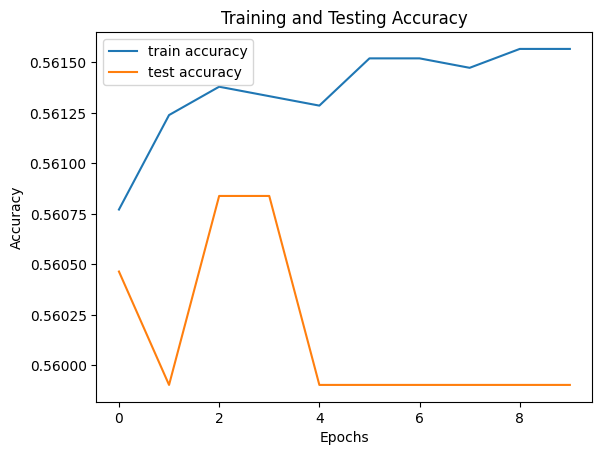

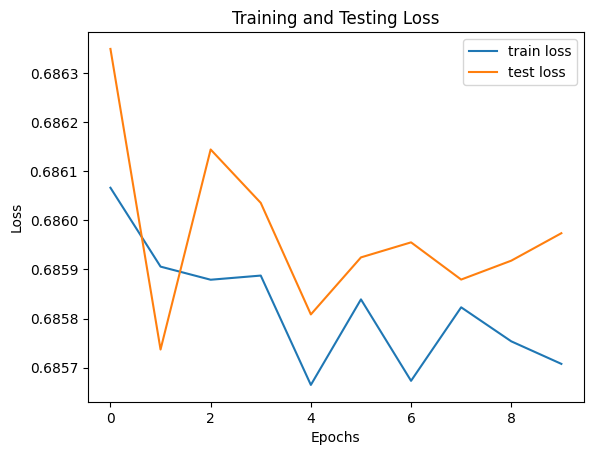

In [ ]:
import matplotlib.pyplot as plt

# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.title('Training and Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.title('Training and Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


FOR K = 3

In [ ]:
# Set the fixed chunk size
k = 3  # Number of chunks per sentence

# Process the data for model input
X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

# Labels for training
y = np.array(data['label'])

# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# Reshaping the data for LSTM input
# LSTM requires input to be in the shape of (samples, time_steps, features)
time_steps = X_train.shape[1]  # Number of chunks
features = X_train.shape[2]    # Number of emotions (6 for anger, disgust, etc.)

# Reshaping to match LSTM input format
X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

# Initialize the LSTM model
model = Sequential()

# Add LSTM layer
model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))  # LSTM layer

# Dropout layer for regularization
model.add(Dropout(0.2))

# Add Dense output layer with 1 unit (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))



/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5589 - loss: 0.6871 - val_accuracy: 0.5541 - val_loss: 0.6874
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5624 - loss: 0.6856 - val_accuracy: 0.5541 - val_loss: 0.6878
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5592 - loss: 0.6864 - val_accuracy: 0.5541 - val_loss: 0.6873
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5585 - loss: 0.6864 - val_accuracy: 0.5541 - val_loss: 0.6875
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5619 - loss: 0.6857 - val_accuracy: 0.5541 - val_loss: 0.6873
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5635 - loss: 0.6852 - val_accuracy: 0.5541 - val_loss: 0.6874
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5576 - loss: 0.6867 - val_accuracy: 0.5535 - val_loss: 0.6875
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5618 - loss: 0.6856 - val_accuracy: 0.

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5668 - loss: 0.6843
Test Loss: 0.6873965263366699
Test Accuracy: 0.5535380244255066


FOR K = 4

In [ ]:
# Set the fixed chunk size
k = 4  # Number of chunks per sentence

# Process the data for model input
X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

# Labels for training
y = np.array(data['label'])

# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshaping the data for LSTM input
# LSTM requires input to be in the shape of (samples, time_steps, features)
time_steps = X_train.shape[1]  # Number of chunks
features = X_train.shape[2]    # Number of emotions (6 for anger, disgust, etc.)

# Reshaping to match LSTM input format
X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

# Initialize the LSTM model
model = Sequential()

# Add LSTM layer
model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))  # LSTM layer

# Dropout layer for regularization
model.add(Dropout(0.2))

# Add Dense output layer with 1 unit (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))



Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5620 - loss: 0.6866 - val_accuracy: 0.5608 - val_loss: 0.6864
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5550 - loss: 0.6870 - val_accuracy: 0.5608 - val_loss: 0.6858
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5621 - loss: 0.6858 - val_accuracy: 0.5608 - val_loss: 0.6858
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5595 - loss: 0.6862 - val_accuracy: 0.5607 - val_loss: 0.6858
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5615 - loss: 0.6857 - val_accuracy: 0.5605 - val_loss: 0.6859
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5553 - loss: 0.6873 - val_accuracy: 0.5607 - val_loss: 0.6858
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5620 - loss: 0.6858 - val_accuracy: 0.5607 - val_loss: 0.6859
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5624 - loss: 0.6855 - val_accuracy: 0.5607 - val_

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5585 - loss: 0.6864
Test Loss: 0.6858234405517578
Test Accuracy: 0.560651421546936


In [ ]:
# Set the fixed chunk size
k = 5  # Number of chunks per sentence

# Process the data for model input
X = process_data_for_model(data, k, emotion_seeds, word_embeddings)

# Labels for training
y = np.array(data['label'])

# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshaping the data for LSTM input
# LSTM requires input to be in the shape of (samples, time_steps, features)
time_steps = X_train.shape[1]  # Number of chunks
features = X_train.shape[2]    # Number of emotions (6 for anger, disgust, etc.)

# Reshaping to match LSTM input format
X_train = X_train.reshape((X_train.shape[0], time_steps, features))
X_test = X_test.reshape((X_test.shape[0], time_steps, features))

# Initialize the LSTM model
model = Sequential()

# Add LSTM layer
model.add(LSTM(64, input_shape=(time_steps, features), return_sequences=False))  # LSTM layer

# Dropout layer for regularization
model.add(Dropout(0.2))

# Add Dense output layer with 1 unit (binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))



Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5552 - loss: 0.6875 - val_accuracy: 0.5607 - val_loss: 0.6858
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5599 - loss: 0.6864 - val_accuracy: 0.5608 - val_loss: 0.6859
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5623 - loss: 0.6858 - val_accuracy: 0.5605 - val_loss: 0.6868
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5595 - loss: 0.6861 - val_accuracy: 0.5607 - val_loss: 0.6861
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5625 - loss: 0.6855 - val_accuracy: 0.5607 - val_loss: 0.6862
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5605 - loss: 0.6859 - val_accuracy: 0.5608 - val_loss: 0.6863
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5711 - loss: 0.6831 - val_accuracy: 0.5607 - val_loss: 0.6863
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5667 - loss: 0.6848 - val_accuracy: 0.5607 - val_

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5584 - loss: 0.6865
Test Loss: 0.6858994960784912
Test Accuracy: 0.560651421546936
